# Golden cross 백테스트

패키지 API(`run_backtest`)로 등록 전략을 실행하는 레퍼런스 노트북입니다.

**커널:** Cursor에서 프로젝트 `.venv`를 고르거나, `uv sync --group notebook` 후 `uv run jupyter lab`.

**데이터 전제:** `data/market-data/curated/daily_prices/`가 있어야 합니다. 없으면:

```bash
uv run market-data backfill --start 2015-01-01
# 또는 스모크: --data-dir data/market-data/test
```

설치·승격 규약은 [노트북 워크벤치](/docs/notebooks.md)를 보세요.

투자 조언을 제공하지 않습니다.

In [1]:
from backtest import available_strategies, plot_backtest, run_backtest, summarize

available_strategies()

['golden_cross']

In [12]:
from datetime import date
from pathlib import Path

security_id = "KRX:005930"
strategy = "golden_cross"
data_dir = Path("data/market-data")
start = date(2020, 1, 1)
end = None
fast = 50
slow = 120
initial_cash = 10_000_000.0
fee_rate = 0.0015

In [13]:
result = run_backtest(
    strategy,
    security_id,
    data_dir=data_dir,
    start=start,
    end=end,
    initial_cash=initial_cash,
    fee_rate=fee_rate,
    fast=fast,
    slow=slow,
)
result

BacktestResult(equity=     trade_date        cash     shares     close        equity  position  \
0    2020-01-02  10000000.0    0.00000   55200.0  1.000000e+07         0   
1    2020-01-03  10000000.0    0.00000   55500.0  1.000000e+07         0   
2    2020-01-06  10000000.0    0.00000   55500.0  1.000000e+07         0   
3    2020-01-07  10000000.0    0.00000   55800.0  1.000000e+07         0   
4    2020-01-08  10000000.0    0.00000   56800.0  1.000000e+07         0   
...         ...         ...        ...       ...           ...       ...   
1609 2026-07-24         0.0  227.54424  249500.0  5.677229e+07         1   
1610 2026-07-27         0.0  227.54424  254000.0  5.779624e+07         1   
1611 2026-07-28         0.0  227.54424  220000.0  5.005973e+07         1   
1612 2026-07-29         0.0  227.54424  208500.0  4.744297e+07         1   
1613 2026-07-30         0.0  227.54424  207000.0  4.710166e+07         1   

      golden_cross  death_cross  
0            False        False

In [14]:
summary = summarize(result)
display(summary)
result.trades

{'initial_cash': 10000000.0,
 'final_equity': 47101657.69125142,
 'total_return': 3.710165769125142,
 'buy_hold_return': 2.75,
 'max_drawdown': -0.4289655172413793,
 'trade_count': 9,
 'bars': 1614}

,trade_date,side,price,shares,fee,cash_after
0,2020-07-23,buy,54700.0,182.541544,14977.533699,0.000000e+00
1,2021-06-07,sell,82700.0,182.541544,22644.278555,1.507354e+07
2,2022-01-12,buy,79500.0,189.320314,22576.447466,0.000000e+00
3,2022-03-24,sell,69600.0,189.320314,19765.040800,1.315693e+07
4,2022-12-09,buy,59300.0,221.538330,19705.834487,0.000000e+00
5,2023-10-10,sell,66200.0,221.538330,21998.756207,1.464384e+07
6,2023-12-12,buy,73300.0,199.480298,21932.858784,0.000000e+00
7,2024-09-11,sell,65100.0,199.480298,19479.251117,1.296669e+07
8,2025-04-03,buy,56900.0,227.544240,19420.900889,0.000000e+00


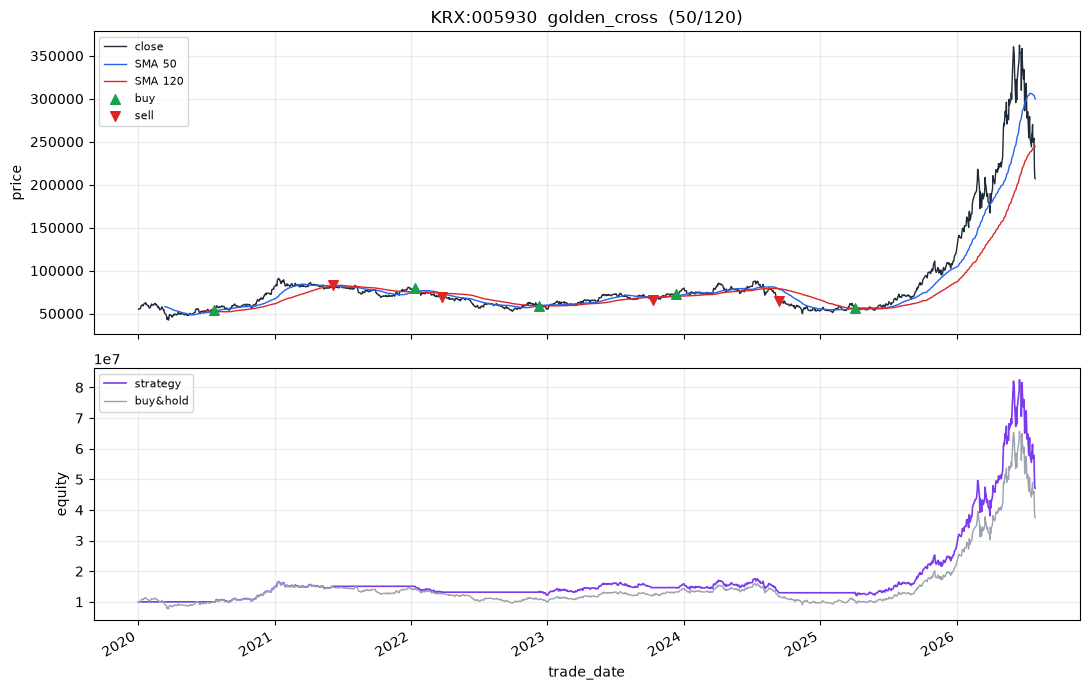

In [15]:
plot_backtest(
    result,
    security_id=security_id,
    strategy=strategy,
    fast=fast,
    slow=slow,
    show=True,
)